In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import openpyxl

In [93]:
data = pd.read_csv("dataset/customer_shopping_data.csv")
data["revenue"] = data["quantity"] * data["price"]

In [94]:
data.head(3)

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall,revenue
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon,7502.00
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul,5401.53
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity,300.08


In [95]:
describe_data = data.describe()
describe_data.to_excel('Results/EDA results/xlsx files/describe of data.xlsx')

In [96]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_no      99457 non-null  object 
 1   customer_id     99457 non-null  object 
 2   gender          99457 non-null  object 
 3   age             99457 non-null  int64  
 4   category        99457 non-null  object 
 5   quantity        99457 non-null  int64  
 6   price           99457 non-null  float64
 7   payment_method  99457 non-null  object 
 8   invoice_date    99457 non-null  object 
 9   shopping_mall   99457 non-null  object 
 10  revenue         99457 non-null  float64
dtypes: float64(2), int64(2), object(7)
memory usage: 8.3+ MB


In [51]:
df.shape

(99457, 11)

In [19]:
# Turn "Invoice_date" from object to date format!
data["invoice_date"] = pd.to_datetime(data["invoice_date"],format='mixed')

In [97]:
data.isnull().sum()

invoice_no        0
customer_id       0
gender            0
age               0
category          0
quantity          0
price             0
payment_method    0
invoice_date      0
shopping_mall     0
revenue           0
dtype: int64

In [23]:
data.groupby(["invoice_no"],as_index=False).size().sort_values(by="size",ascending=False).reset_index(drop=True).head()

,invoice_no,size
0,I100008,1
1,I312466,1
2,I312529,1
3,I312524,1
4,I312523,1


#### Using age group which selected from "UN recommended standard international age classification" (source: chatgpt)
1. [ 0 - 14 ] : Childern
2. [ 15 - 24 ] : Youth
3. [ 25 - 64 ] : Adults
4. [ 65 - 99 ] : Older Adults

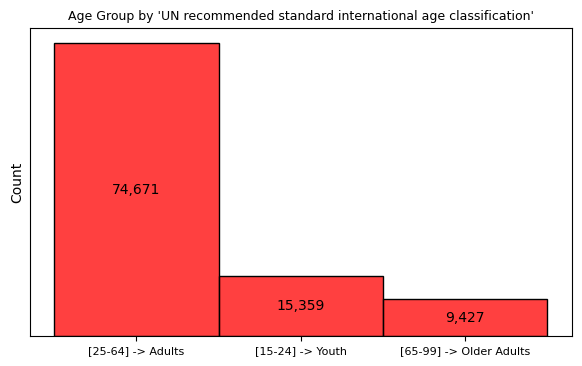

In [84]:
df_age = data.copy()

# Age group
df_age["age_group"] = df["age"].map(lambda x: "[0-14] -> Children" if x<15 
                                    else "[15-24] -> Youth" if x<26 
                                    else "[25-64] -> Adults" if x<65 
                                    else "[65-99] -> Older Adults")

# Plotting age group to see age distribution
plt.figure(figsize=(7,4))
ax=sns.histplot(data=df_age,x="age_group",color="red")
for container in ax.containers:
    ax.bar_label(container, labels=[f"{v:,.0f}" for v in container.datavalues],label_type="center")
plt.title("Age Group by 'UN recommended standard international age classification'",fontsize=9)
plt.xlabel("")
plt.xticks(fontsize=8)
plt.yticks([])

plt.savefig("Results/EDA results/plots/Age Group.png")
plt.show()

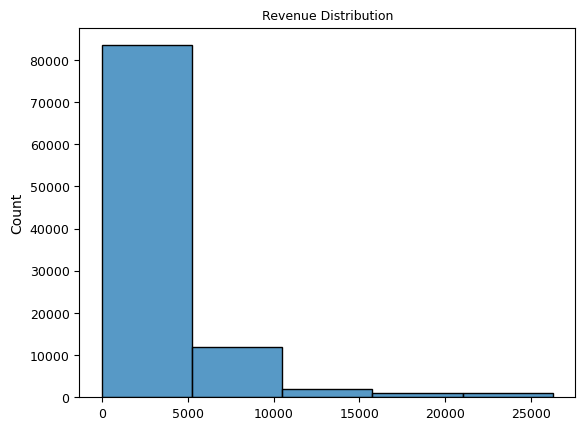

In [98]:
sns.histplot(data=data,x="revenue",bins=5)
plt.title("Revenue Distribution",fontsize=9)
plt.xlabel("")
plt.ylabel("Count",fontsize=10)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)

plt.savefig("Results/EDA results/plots/Revenue Distribution.png")
plt.show()

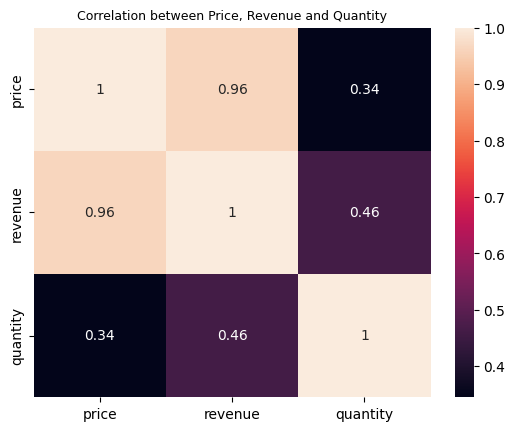

In [108]:
correlation = data[["price","revenue","quantity"]].corr()
sns.heatmap(correlation,annot=True)
plt.title("Correlation between Price, Revenue and Quantity",fontsize=9)

plt.savefig("Results/EDA results/plots/Correlation(Price,Revenue,Quantity).png")
plt.show()